# Assignment 5

Assume you work for a record company. Your boss is interested in predicting ablum sales based on advertising. You are provided with the data in a file (*album_sales.csv*). 

There are 200 rows, where each row represents an album. There are also four columns. The first (*sales*) represents the sales of each album (in thousands) the week after release. The second (adverts) represents the amount (in thousands $) spent promoting the album prior to its release. The third (*airplay*) represents how many times it played on the radio. The fourth column (*attract*) represents the attractiveness of the band. 

## Instructions

### 1. Visualization (15 points)

Visualizing data is important to get a 'feel' of what the relationship between variables could be. For this part, **display the scatterplots between the following variables**.

- *sales* and *adverts*
- *sales* and *airplay*
- *sales* and *attract*

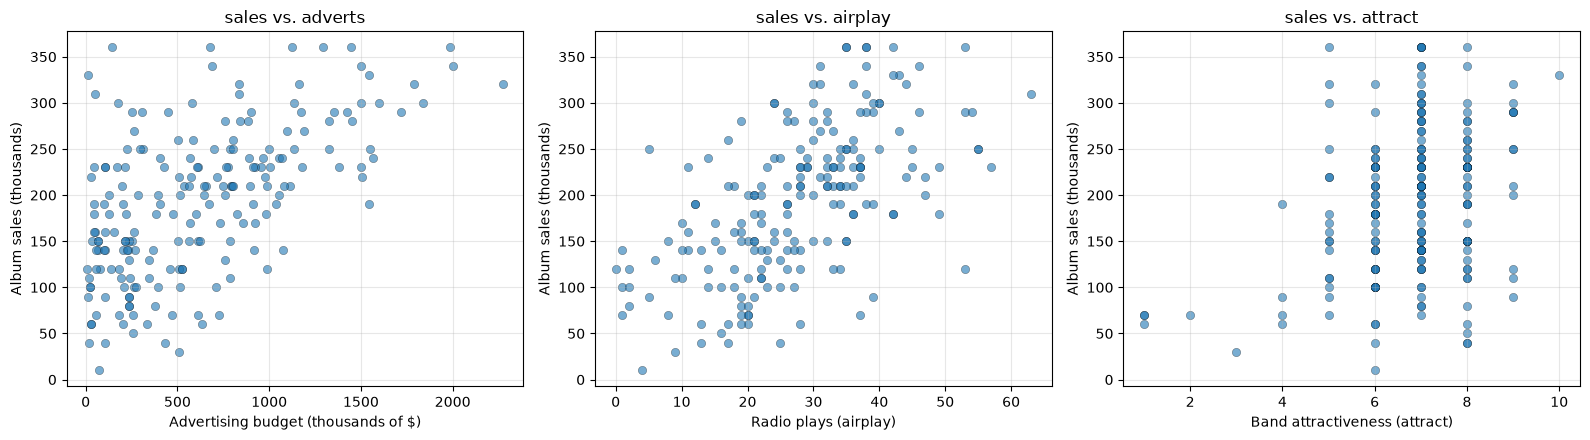

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("./album_sales.csv")

predictors = [
    ("adverts", "Advertising budget (thousands of $)"),
    ("airplay", "Radio plays (airplay)"),
    ("attract", "Band attractiveness (attract)"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (col, label) in zip(axes, predictors):
    ax.scatter(df[col], df["sales"], alpha=0.6, edgecolor="k", linewidth=0.3)
    ax.set_xlabel(label)
    ax.set_ylabel("Album sales (thousands)")
    ax.set_title(f"sales vs. {col}")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In the empty `Markdown` cell below, describe the relationship (or lack thereof) portrayed by the scatterplots you generated. 

All three scatterplots show a **positive** relationship with *sales*: albums with more advertising, more airplay, or a more attractive band tend to sell more.

- **sales vs. adverts:** A moderate, roughly linear, upward trend (correlation of about 0.58). There is a lot of scatter around the trend at every budget level, so advertising alone does not pin down sales; albums with similar budgets can sell very differently.
- **sales vs. airplay:** A similar moderate, roughly linear upward trend (correlation of about 0.60), with a fairly even spread around the trend.
- **sales vs. attract:** The weakest of the three (correlation of about 0.33). *attract* only takes whole-number ratings, so the points form vertical stripes. Sales tick upward as the rating rises, but the stripes overlap heavily, so there is a lot of variation in sales at every rating.

Overall, *adverts* and *airplay* look like the more useful predictors, and *attract* appears to be a smaller contributor.

### 2. Linear Regression (35 points)

- Conduct a linear regression to construct a linear model between *sales* and *adverts*
- Display the **F-statistic** and **P-value**
    - Use the `statsmodels.api` module for this -- may need to install via `pip`
    - Note that **X**, your predictor(s), will consist of *adverts* and that **y**, your constant, will consist of *sales*
    - The values you need can be accessed via the `summary()` function of your model object

In [ ]:
import statsmodels.api as sm

#1: sales/adverts
y = df["sales"]
X1 = sm.add_constant(df[["adverts"]])   # adds the intercept term

model1 = sm.OLS(y, X1).fit()
print(model1.summary())

print(f"\nF-statistic: {model1.fvalue:.2f}")
print(f"P-value (F-test): {model1.f_pvalue:.3e}")

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     99.59
Date:                Sat, 19 Sep 2026   Prob (F-statistic):           2.94e-19
Time:                        17:05:28   Log-Likelihood:                -1120.7
No. Observations:                 200   AIC:                             2245.
Df Residuals:                     198   BIC:                             2252.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        134.1399      7.537     17.799      0.0

In the empty `Markdown` cell below, describe whether the **F-statistic** and **P-value** describe about our linear regression model. (I.e., Is it good? Bad? No bearing?)

The **F-statistic is about 99.6** with a **P-value of about 2.9 × 10⁻¹⁹**. The P-value is far below 0.05, so we reject the null hypothesis that *adverts* has no effect on *sales*. The model is statistically significant, and it predicts sales better than simply using the average sales figure.

However, "significant" does not mean "strong." The R² for this model is only about 0.335, so advertising explains roughly a third of the variation in album sales and the other two-thirds is left unexplained. So the F-statistic and P-value say the model is **good in the sense that it is meaningful (not just noise)**, but it is **incomplete**, and other variables (such as airplay and band attractiveness) likely matter too.

### 3. Model Coefficients (10 points)

- Make note of the **intercept** value and **coefficient** (adverts) value of your linear regression model. 

The regression line is described using this equation: *Y = b<sub>0</sub> + b<sub>1</sub>X<sub>1</sub>* where each variable represents the following:

- Y denotes the sales
- *b<sub>0</sub>* denotes the **intercept** value
- *b<sub>1</sub>* denotes the advertising budget **coefficient**
- *X<sub>2</sub>* denotes the advertising budget

The equation then becomes *Album Sales = intercept value + (coefficient * advertising budget)*. 

Using the intercept value and coefficient of your linear model, **calculate and display how many records will be sold if $135,000 was spent on advertising an album**.

In [ ]:
intercept = model1.params["const"]        # b0
coefficient = model1.params["adverts"]    # b1

print(f"Intercept (b0):            {intercept:.4f}")
print(f"Advertising coefficient (b1): {coefficient:.4f}")

# adverts measured in thousands, so $135,000 -> 135
advertising_budget = 135
predicted_sales = intercept + coefficient * advertising_budget   # in thousands of records

print(f"\nAlbum Sales = {intercept:.4f} + ({coefficient:.4f} * {advertising_budget})")
print(f"Predicted sales: {predicted_sales:.2f} thousand records (about {predicted_sales * 1000:,.0f} records)")

Intercept (b0):            134.1399
Advertising coefficient (b1): 0.0961

Album Sales = 134.1399 + (0.0961 * 135)
Predicted sales: 147.12 thousand records (about 147,117 records)


### 4. Multiple Regression (40 points)
- Conduct a **multiple regression** to construct a model between *sales* and the predictors (*adverts*, *airplay*, and *attract*)
    - Note that **X**, your predictors will consist of *adverts*, *airplay*, and *attractiveness*, and **y**, your constant, will consist of *sales*
- Display the summary of the multiple regression model using the `summary()` function to obtain the relevant values

In [ ]:
#2: sales/adverts + airplay + attract
X2 = sm.add_constant(df[["adverts", "airplay", "attract"]])

model2 = sm.OLS(y, X2).fit()
print(model2.summary())

print("\n--- Model comparison ---")
print(f"Model 1: R2 = {model1.rsquared:.3f}, Adj. R2 = {model1.rsquared_adj:.3f}, F-test P-value = {model1.f_pvalue:.2e}")
print(f"Model 2: R2 = {model2.rsquared:.3f}, Adj. R2 = {model2.rsquared_adj:.3f}, F-test P-value = {model2.f_pvalue:.2e}")

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     129.5
Date:                Sat, 19 Sep 2026   Prob (F-statistic):           2.88e-46
Time:                        17:05:28   Log-Likelihood:                -1052.2
No. Observations:                 200   AIC:                             2112.
Df Residuals:                     196   BIC:                             2126.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -26.6130     17.350     -1.534      0.1

We know that the R<sup>2</sup> (R-Squared) value can be used to evaluate the overall fit of a linear model. We also know that R<sup>2</sup> is between 0 and 1 -- higher values are better because it means that more variance is explained by the model. **Higher R<sup>2</sup> values are better if their P-values are < 0.05**.

Bsed on this, discuss **which one of the two models you constructed is better** in the empty `Markdown` cell below. 
* Model 1: The linear model between *sales* and *adverts* you constructed
* Model 2: The multiple regression model between (*sales*) and the predictors (*adverts*, *airplay*, and *attract*) you constructed

**Model 2 (the multiple regression) is the better model.**

| | Model 1 (adverts) | Model 2 (adverts, airplay, attract) |
|---|---|---|
| R² | 0.335 | 0.665 |
| Adjusted R² | 0.331 | 0.660 |
| F-test P-value | 2.9 × 10⁻¹⁹ | 2.9 × 10⁻⁴⁶ |

Both models have P-values well below 0.05, so both are statistically significant and R² can be compared fairly. Model 2 explains about **66.5%** of the variance in sales, roughly double Model 1's **33.5%**. Adding predictors always nudges R² up, so it is worth checking adjusted R², which penalizes extra variables. It also jumps from 0.331 to 0.660, so the improvement is real and not just an artifact of having more predictors.

In Model 2, *adverts*, *airplay*, and *attract* each have P-values below 0.05 (all ≈ 0.000), so every predictor contributes something useful. (The intercept is not significant, but that is not a concern here.) Sales depend on more than advertising alone, and using all three predictors gives a much better fit.

### Submission
- Submit this `Jupyter` file to D2L, renamed as **Last_First_Assignment4.ipynb** 
    - Replace '**Last**' and '**First**' with your first and last name